# fig3d: spikes

**author**: laquitainesteeve@gmail.com

**purpose**: plot the spatial variations of a simulated action potential

**tested on**:
* Ubuntu 24.04.1 LTS (32 cores, 188 GB RAM, Intel(R) Core(TM) i9-14900K ＠3.2 GHz/5.8 GHz) with RTX 5090 GPU with 40GB VRAM (GPU not needed)

**Execution time**: 40 secs

## Setup

1. Setup "_envs/spikebias.yml_" virtual environment
2. Setup jupyter kernel _$python -m ipykernel install --user --name spikebias --display-name "spikebias"_
3. Download "_sub-biophy-isolated-traces-reyes/sub-biophy-isolated-traces-reyes_ses-006_ecephys.nwb_" with 0_download_recordings.ipynb 
4. Download Ground truth spikes of cell 3754013 with 0_download_ground_truths.ipynb

In [ ]:
%%time
import os
import neurom as nm
from neurom.view import plotly_impl
from neurom.view import matplotlib_impl
import yaml 
import spikeinterface as si
import numpy as np
import pandas as pd
import matplotlib 
from matplotlib import pyplot as plt;
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", module="matplotlib")
print('Spikeinterface version:', si.__version__)

# move to project path
proj_path = "/home/steeve/steeve/epfl/code/spikebias/"
os.chdir(proj_path)

# setup cell parameters
CELL = '3754013'                                                  # the most active pyramidal cell (layer 5)
CELL_POS = np.array([3820.476353, -1143.5028, -2538.452514])    # its position in the cortical column

# setup paths
RECORDING_PATH = 'dataset/00_raw/recording_reyes_isolated_traces'
GT_PATH = 'dataset/00_raw/ground_truth_reyes_isolated_traces'

# install chrome to save as svg figures
# !plotly_get_chrome -y

# setup waveform parameters
# 200 points before and 200 points after the 
# spike timestamp at 20 KHz <-> 20 ms
MS_BEFORE = 10

# figure axes
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6  # 5-7 with Nature neuroscience as reference
plt.rcParams["lines.linewidth"] = 0.5 # typically between 0.5 and 1
plt.rcParams["axes.linewidth"] = 0.5 #1
plt.rcParams["axes.spines.top"] = False
plt.rcParams["xtick.major.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["xtick.minor.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["ytick.major.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["ytick.minor.width"] = 0.5 #0.8 #* 1.3
plt.rcParams["xtick.major.size"] = 3.5 * 1.1
plt.rcParams["xtick.minor.size"] = 2 * 1.1
plt.rcParams["ytick.major.size"] = 3.5 * 1.1
plt.rcParams["ytick.minor.size"] = 2 * 1.1

# figure save
savefig_cfg = {"transparent":True, "dpi": 400}
savefig_png_cfg = {"transparent":True, "dpi": 900}

legend_cfg = {"frameon": False, "handletextpad": 0.5}
tight_layout_cfg = {"pad": 0.5}

Spikeinterface version: 0.100.8
CPU times: user 2.41 s, sys: 38.8 ms, total: 2.45 s
Wall time: 419 ms


## Functions

In [2]:
def get_unit_waveform(trace, spike_time, timepoint_before=60, timepoint_after=60):
    """
    Extracts waveforms of a unit from the given trace based on spike times.

    Parameters:
        trace (numpy.ndarray): The signal trace from which waveforms are extracted.
        spike_time (list or numpy.ndarray): The spike times (in samples) for the unit.
        timepoint_before (int): Number of samples to include before the spike time.
        timepoint_after (int): Number of samples to include after the spike time.

    Returns:
        list: A list of waveforms, each corresponding to a spike.
    """
    waveform = []
    for spike in spike_time:
        this_waveform = trace[
            int(spike - timepoint_before) : int(spike + timepoint_after)
        ]
        waveform.append(this_waveform)
    return waveform


def shrink_to_mean(arr, factor=0.5):
    mean = arr.mean()
    return mean + (arr - mean) * factor


def extract_morph_lines(cell, neurite_type, color, alpha, linewidth, plane="xy"):
    """Extract line data from a plot_morph call into a dataframe."""
    fig_tmp, ax_tmp = plt.subplots()
    matplotlib_impl.plot_morph(
        cell,
        plane=plane,
        soma_outline=False,
        neurite_type=neurite_type,
        color=color,
        ax=ax_tmp,
        alpha=alpha,
        linewidth=linewidth,
    )
    records = []
    for i, line in enumerate(ax_tmp.get_lines()):
        for x, y in zip(line.get_xdata(), line.get_ydata()):
            records.append({"line_id": i, "x": x, "y": y})
    for i, col in enumerate(ax_tmp.collections):
        for path in col.get_paths():
            for x, y in path.vertices:
                records.append({"line_id": f"col_{i}", "x": x, "y": y})
    plt.close(fig_tmp)
    df = pd.DataFrame(records)
    df["color"] = str(color)
    df["alpha"] = alpha
    df["linewidth"] = linewidth
    df["neurite_type"] = str(neurite_type).split(".")[-1]
    return df

## Load dataset

In [3]:
# load recording
Recording = si.load_extractor(RECORDING_PATH)  # recording traces

# load ground truth spike timestamps
Gt = si.load_extractor(GT_PATH)  # ground truth spike timestamps

# load cell morphology data
cell = nm.load_morphology("assets/morph_cell_3754013.h5")

## Compute data

In [ ]:
%%time 

# color legend defined in neurom.view.matplotlib_impl.py
#     NeuriteType.basal_dendrite: 'red',
#     NeuriteType.apical_dendrite: 'purple',
#     NeuriteType.axon: 'blue',
#     NeuriteType.soma: 'black',
#     NeuriteType.undefined: 'green',
#     NeuriteType.custom5: 'orange',
#     NeuriteType.custom6: 'orange',
#     NeuriteType.custom7: 'orange',
#     NeuriteType.custom8: 'orange',
#     NeuriteType.custom9: 'orange',
#     NeuriteType.custom10: 'orange',


# get electrode positions
site_pos = si.load_extractor(RECORDING_PATH).get_property('location')
print("site coordinates:\n", site_pos)

# get spike train
spike_sample = Gt.get_unit_spike_train(CELL)

# get traces and its parameters
cell_traces = Recording.get_traces()
rec_duration_sec = Recording.get_total_duration()
sfreq = Recording.sampling_frequency
timepoints_before = MS_BEFORE * sfreq / 1000
time_sec = np.arange(0, rec_duration_sec, 1 / sfreq)

# calculate median spike (template) per channel (1 sec)
contact_ids = np.arange(0, 128, 1)

# get all waveforms by electrode site
wavef_by_channel = []
for channel_i in range(len(contact_ids)):
    wvs = get_unit_waveform(
        cell_traces[:, channel_i],
        spike_sample,
        timepoint_before=timepoints_before,
        timepoint_after=timepoints_before,
    )
    min_len = min([len(ix) for ix in wvs])
    wv2 = []
    for wv in wvs:
        wv2.append(wv[:min_len])
    mean_wavef = np.mean(np.array(wv2), axis=0)
    wavef_by_channel.append(mean_wavef)
all_spikes = np.array(wavef_by_channel)
all_spikes = all_spikes.T

# setup electrode site ids in an array
contact_ids = np.arange(0, 128, 1)
contact_grid = contact_ids.reshape(8, 16)

# setup waveform negative peak-to- positive peak color schemes
# - get peak to peak amplitude (ppa)
min_s = all_spikes.min(axis=0)
max_s = all_spikes.max(axis=0)
peak_to_peak_amp = max_s - min_s

# - map ppa to spike templates (logscale)
df = pd.DataFrame(
    {"ppa": np.log10(peak_to_peak_amp), "contact": np.arange(0, 128, 1)}
).sort_values(by="ppa", ascending=True)

# - convert peak to peak amplitude to color gradient
color_intensity = (df["ppa"] - df["ppa"].min()) / (df["ppa"].max() - df["ppa"].min())
cmap = plt.cm.viridis(color_intensity)
df["colors"] = cmap.tolist()
df = df.sort_values(by="contact")

# - convert colors to RGB for plotly
arr = np.array(df["colors"].values.tolist(), dtype=float)
rgba_colors = [f"rgba({int(r*255)}, {int(g*255)}, {int(b*255)}, {a})" for r, g, b, a in arr]

site coordinates:
 [[ 3333.81242423 -1841.70092968 -2941.78131262]
 [ 3378.99014513 -1853.02392971 -2882.99557282]
 [ 3424.16786603 -1864.34692974 -2824.20983301]
 [ 3469.34558693 -1875.66992978 -2765.42409321]
 [ 3514.52330784 -1886.99292981 -2706.63835341]
 [ 3559.70102874 -1898.31592985 -2647.8526136 ]
 [ 3604.87874964 -1909.63892988 -2589.0668738 ]
 [ 3650.05647054 -1920.96192992 -2530.28113399]
 [ 3695.23419145 -1932.28492995 -2471.49539419]
 [ 3740.41191235 -1943.60792999 -2412.70965439]
 [ 3785.58963325 -1954.93093002 -2353.92391458]
 [ 3830.76735415 -1966.25393005 -2295.13817478]
 [ 3875.94507506 -1977.57693009 -2236.35243498]
 [ 3921.12279596 -1988.89993012 -2177.56669517]
 [ 3966.30051686 -2000.22293016 -2118.78095537]
 [ 4011.47823777 -2011.54593019 -2059.99521557]
 [ 3382.43500685 -1647.70133056 -2941.78131262]
 [ 3427.61272776 -1659.02433059 -2882.99557282]
 [ 3472.79044866 -1670.34733062 -2824.20983301]
 [ 3517.96816956 -1681.67033066 -2765.42409321]
 [ 3563.14589046 -169

## Plot

CPU times: user 540 ms, sys: 2.03 ms, total: 542 ms
Wall time: 542 ms


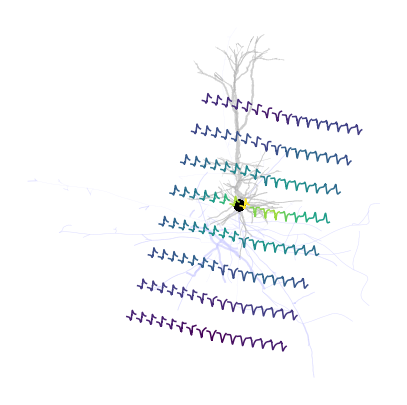

In [5]:
%%time 

# setup parameters
Y_SCALE = 30
X_SHRINK = 0.1
ALPHA = 0.8
LW = 1

# setup plot
fig, ax = plt.subplots(figsize=(5, 5)) # width, height in inches

# color axon in blue
matplotlib_impl.plot_morph(cell, plane="xy", soma_outline=False, neurite_type=nm.NeuriteType.axon, color=(0.8,0.8,1), ax=ax, alpha=ALPHA, linewidth=LW)

# color basal dendrites in lighter grey
matplotlib_impl.plot_morph(cell, plane="xy", soma_outline=False, neurite_type=nm.NeuriteType.basal_dendrite, color=(0.7,0.7,0.7), ax=ax, alpha=ALPHA, linewidth=LW)

# color apical dendrites in lighter grey
matplotlib_impl.plot_morph(cell, plane="xy", soma_outline=False, neurite_type=nm.NeuriteType.apical_dendrite, color=(0.7,0.7,0.7), ax=ax, alpha=ALPHA, linewidth=LW)

wave_x_all = []
wave_y_all = []

# plot waveform at each electrode site
for s_ix in np.arange(0, 128):

    # setup waveforms
    # - center and scale waveform at electrode site
    waveform = all_spikes[:, s_ix]
    y_centered = (waveform - waveform.mean())
    y_normalized = 2 * (y_centered - y_centered.min()) / (y_centered.max() - y_centered.min())-1

    # - place waveform at site location
    wavform_x_centered = len(waveform)/2
    wave_x = site_pos[[s_ix], 0] - CELL_POS[0] + np.arange(0, len(waveform),1) - wavform_x_centered
    wave_x = shrink_to_mean(wave_x, X_SHRINK)

    # - scale waveform amplitude for visibility
    y_scaled = y_normalized * Y_SCALE # scale waveform for visibility
    y0_is_0 = y_scaled - y_scaled[0] # normalize all waveform to be 0 at x=0.
    wave_y = site_pos[[s_ix], 1] - CELL_POS[1] + y0_is_0

    # plot soma
    ax.plot(cell.soma.center[0], cell.soma.center[1], color='k', marker='o', markerfacecolor='k', markersize=7, linewidth=1, label='soma')

    # plot waveform at this site
    ax.plot(wave_x, wave_y, color=arr[s_ix,:], linewidth=1.1, label='waveform', zorder=1000)

    # record source data
    wave_x_all.append(wave_x)
    wave_y_all.append(wave_y)

# aesthetics
ax.set_title("")
ax.set_axis_off()

# save figure
plt.savefig("figures/8_source_data/fig3d/fig3d.svg", **savefig_cfg)

### Create source data

In [6]:
# format spike data ---------------------------------------------------

# make arrays
wave_x_all = np.array(wave_x_all)
wave_y_all = np.array(wave_y_all)
color_array = arr

n_spikes, n_samples = wave_x_all.shape  # 128, 400

records = []

# loop over spikes
for spike_id in range(n_spikes):

    # loop over time samples
    for t in range(n_samples):

        # record data
        records.append(
            {
                "spike_id": spike_id,
                "time": wave_x_all[spike_id, t],
                "voltage": wave_y_all[spike_id, t],
                "r": color_array[spike_id, 0],
                "g": color_array[spike_id, 1],
                "b": color_array[spike_id, 2],
                "a": color_array[spike_id, 3],
            }
        )

# make dataframe
df_spikes = pd.DataFrame(records)


# format cell morphology data ---------------------------------------------------

records = []

neurite_configs = [
    (nm.NeuriteType.axon, "axon"),
    (nm.NeuriteType.basal_dendrite, "basal_dendrite"),
    (nm.NeuriteType.apical_dendrite, "apical_dendrite"),
]

for ntype, neurite_name in neurite_configs:
    filt = lambda n, nt=ntype: n.type == nt
    for n_id, neurite in enumerate(nm.iter_neurites(cell, filt=filt)):
        for s_id, section in enumerate(neurite.sections):
            pts = section.points
            for p in pts:
                records.append(
                    {
                        "x": p[0],
                        "y": p[1],
                        "neurite_type": neurite_name,
                        "neurite_id": n_id,
                        "section_id": s_id,
                    }
                )
df_morph = pd.DataFrame(records)

# save neurites data to excel file
df_spikes.to_excel("figures/8_source_data/fig3d/fig3d_spikes.xlsx", index=False)
df_morph.to_excel("figures/8_source_data/fig3d/fig3d_cell_morphology.xlsx", index=False)

# display spike data
display(df_spikes)

,spike_id,time,voltage,r,g,b,a
0,0,-507.113929,-698.198130,0.283072,0.130895,0.449241,1.0
1,0,-507.013929,-698.227335,0.283072,0.130895,0.449241,1.0
2,0,-506.913929,-698.257875,0.283072,0.130895,0.449241,1.0
3,0,-506.813929,-698.288768,0.283072,0.130895,0.449241,1.0
4,0,-506.713929,-698.320212,0.283072,0.130895,0.449241,1.0
...,...,...,...,...,...,...,...
51195,127,550.409963,475.154957,0.263663,0.237631,0.518762,1.0
51196,127,550.509963,475.235956,0.263663,0.237631,0.518762,1.0
51197,127,550.609963,475.316221,0.263663,0.237631,0.518762,1.0
51198,127,550.709963,475.395725,0.263663,0.237631,0.518762,1.0


In [29]:
# display cell morphology data
display(df_morph)

,x,y,neurite_type,neurite_id,section_id
0,2.235122,-15.267311,axon,0,0
1,2.079638,-19.991737,axon,0,0
2,1.923724,-25.507627,axon,0,0
3,1.791589,-30.984360,axon,0,0
4,1.618733,-35.698277,axon,0,0
...,...,...,...,...,...
12469,96.889221,72.491364,apical_dendrite,0,145
12470,104.111664,74.903679,apical_dendrite,0,145
12471,110.904732,77.956429,apical_dendrite,0,145
12472,118.385147,79.846733,apical_dendrite,0,145


### Plot source data

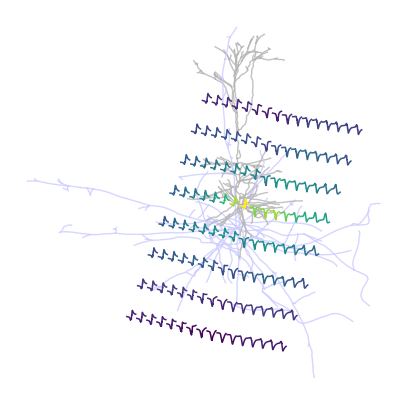

In [13]:
neurite_colors = {
    "axon": (0.8, 0.8, 1.0),
    "basal_dendrite": (0.7, 0.7, 0.7),
    "apical_dendrite": (0.7, 0.7, 0.7),
}

neurite_alpha = {
    "axon": ALPHA,
    "basal_dendrite": ALPHA,
    "apical_dendrite": ALPHA,
}

# setup plot
fig, ax = plt.subplots(figsize=(5, 5))

# plot cell neurites
for (neurite_type, neurite_id, section_id), data in df_morph.groupby(
    ["neurite_type", "neurite_id", "section_id"]
):
    ax.plot(
        data["x"],
        data["y"],
        color=neurite_colors[neurite_type],
        linewidth=LW,
        alpha=neurite_alpha[neurite_type],
    )

# plot spike at each electrode site
for spike_id, group in df_spikes.groupby("spike_id"):
    color = group[["r", "g", "b", "a"]].iloc[0].values
    ax.plot(group["time"], group["voltage"], color=color, zorder=1000, linewidth=1.1)

# aesthetics
ax.set_title("")
ax.set_axis_off()

### Colorbar

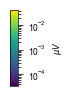

In [31]:
# save log scale colorbar
fig, ax = plt.subplots(figsize=(0.1, 2))
fig.subplots_adjust(bottom=0.5)
cmap = matplotlib.cm.viridis
norm = matplotlib.colors.LogNorm(
    vmin=peak_to_peak_amp.min(), vmax=peak_to_peak_amp.max()
)
cbar = fig.colorbar(
    matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=ax,
    orientation="vertical",
    label="$\mu V$",
)

# save figure
plt.savefig(
    "figures/8_source_data/fig3d/fig3d_colorbar.svg", bbox_inches="tight", **savefig_cfg
)